# Task 5: Object Detection and Image Segmentation

## Objective
To develop computer vision systems capable of object detection and image segmentation.

## Reference Dataset
PASCAL VOC 2012 Dataset

## Models Used
1. Faster R-CNN for Object Detection
2. U-Net for Semantic Segmentation

## Evaluation Metrics
- Mean Average Precision (mAP)
- Intersection over Union (IoU)
- Dice Score

## Deliverables
- Object detection implementation
- Object localization and detection
- Semantic segmentation implementation
- Performance evaluation
- Prediction visualizations
- Comparative analysis

In [1]:
!pip -q install torchmetrics pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 30.8 MB/s eta 0:00:00


In [2]:
import os
import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision
from torchvision import transforms
from torchvision.datasets import VOCDetection, VOCSegmentation
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn,
    FasterRCNN_ResNet50_FPN_Weights
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from torchmetrics.detection import MeanAveragePrecision

import xml.etree.ElementTree as ET

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)

PyTorch: 2.11.0+cu130
Torchvision: 0.26.0+cu130


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [4]:
VOC_ROOT = "/content/pascal_voc"

# Detection dataset
voc_detection_train = VOCDetection(
    root=VOC_ROOT,
    year="2012",
    image_set="train",
    download=True
)

voc_detection_val = VOCDetection(
    root=VOC_ROOT,
    year="2012",
    image_set="val",
    download=True
)

print("PASCAL VOC 2012 Detection Dataset Loaded")
print("Training images:", len(voc_detection_train))
print("Validation images:", len(voc_detection_val))

100%|██████████| 2.00G/2.00G [00:12<00:00, 160MB/s]


PASCAL VOC 2012 Detection Dataset Loaded
Training images: 5717
Validation images: 5823


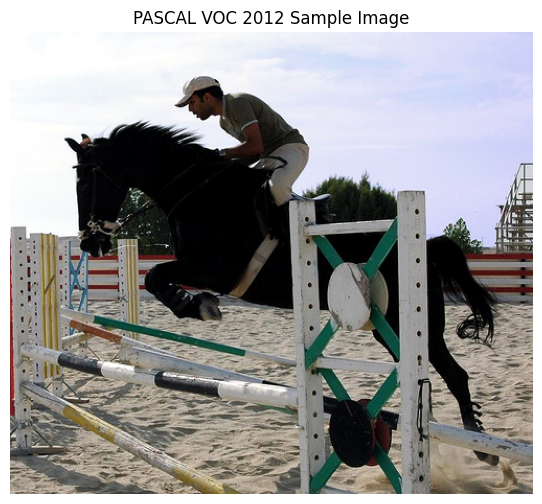

In [5]:
image, annotation = voc_detection_train[0]

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.title("PASCAL VOC 2012 Sample Image")
plt.show()

In [6]:
VOC_CLASSES = [
    "background",
    "aeroplane",
    "bicycle",
    "bird",
    "boat",
    "bottle",
    "bus",
    "car",
    "cat",
    "chair",
    "cow",
    "diningtable",
    "dog",
    "horse",
    "motorbike",
    "person",
    "pottedplant",
    "sheep",
    "sofa",
    "train",
    "tvmonitor"
]

CLASS_TO_ID = {
    name: idx for idx, name in enumerate(VOC_CLASSES)
}

print("Number of classes:", len(VOC_CLASSES))
print(VOC_CLASSES)

Number of classes: 21
['background', 'aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']


In [7]:
class VOCDetectionDataset(Dataset):

    def __init__(self, root, year="2012", image_set="train"):
        self.dataset = VOCDetection(
            root=root,
            year=year,
            image_set=image_set,
            download=True
        )

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        image, target = self.dataset[idx]

        image = transforms.ToTensor()(image)

        objects = target["annotation"].get("object", [])

        if not isinstance(objects, list):
            objects = [objects]

        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for obj in objects:

            bbox = obj["bndbox"]

            xmin = float(bbox["xmin"])
            ymin = float(bbox["ymin"])
            xmax = float(bbox["xmax"])
            ymax = float(bbox["ymax"])

            # Make sure coordinates are valid
            if xmax <= xmin or ymax <= ymin:
                continue

            boxes.append([xmin, ymin, xmax, ymax])

            class_name = obj["name"].lower().strip()

            if class_name in CLASS_TO_ID:
                labels.append(CLASS_TO_ID[class_name])
            else:
                continue

            areas.append((xmax - xmin) * (ymax - ymin))

            difficult = int(obj.get("difficult", 0))
            iscrowd.append(difficult)

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        areas = torch.as_tensor(areas, dtype=torch.float32)
        iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)

        target_dict = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "area": areas,
            "iscrowd": iscrowd
        }

        return image, target_dict

In [8]:
train_detection_dataset = VOCDetectionDataset(
    root=VOC_ROOT,
    year="2012",
    image_set="train"
)

val_detection_dataset = VOCDetectionDataset(
    root=VOC_ROOT,
    year="2012",
    image_set="val"
)

print("Train:", len(train_detection_dataset))
print("Validation:", len(val_detection_dataset))

Train: 5717
Validation: 5823


In [9]:
DET_TRAIN_SIZE = min(300, len(train_detection_dataset))
DET_VAL_SIZE = min(100, len(val_detection_dataset))

train_detection_dataset = Subset(
    train_detection_dataset,
    range(DET_TRAIN_SIZE)
)

val_detection_dataset = Subset(
    val_detection_dataset,
    range(DET_VAL_SIZE)
)

print("Detection training samples:", len(train_detection_dataset))
print("Detection validation samples:", len(val_detection_dataset))

Detection training samples: 300
Detection validation samples: 100


In [10]:
def detection_collate_fn(batch):
    return tuple(zip(*batch))


train_detection_loader = DataLoader(
    train_detection_dataset,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    collate_fn=detection_collate_fn
)

val_detection_loader = DataLoader(
    val_detection_dataset,
    batch_size=2,
    shuffle=False,
    num_workers=0,
    collate_fn=detection_collate_fn
)

print("Detection DataLoaders created successfully.")

Detection DataLoaders created successfully.


In [11]:
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT

model = fasterrcnn_resnet50_fpn(
    weights=weights,
    min_size=400,
    max_size=600
)

# Number of classes = 20 VOC classes + background
num_classes = len(VOC_CLASSES)

# Replace the COCO classification head
in_features = model.roi_heads.box_predictor.cls_score.in_features

model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

model = model.to(device)

print("Faster R-CNN model created.")
print("Number of classes:", num_classes)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 150MB/s]


Faster R-CNN model created.
Number of classes: 21


In [12]:
params = [
    p for p in model.parameters()
    if p.requires_grad
]

optimizer = optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

num_epochs = 2

detection_losses = []

print("Starting Faster R-CNN training...")

for epoch in range(num_epochs):

    model.train()

    epoch_loss = 0.0

    for batch_idx, (images, targets) in enumerate(train_detection_loader):

        images = [
            img.to(device)
            for img in images
        ]

        targets = [
            {
                k: v.to(device)
                for k, v in target.items()
            }
            for target in targets
        ]

        optimizer.zero_grad()

        loss_dict = model(
            images,
            targets
        )

        losses = sum(
            loss for loss in loss_dict.values()
        )

        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

    avg_loss = epoch_loss / len(train_detection_loader)

    detection_losses.append(avg_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {avg_loss:.4f}"
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Faster R-CNN training completed.")

Starting Faster R-CNN training...
Epoch [1/2] Loss: 0.6496
Epoch [2/2] Loss: 0.4484
Faster R-CNN training completed.


In [13]:
params = [
    p for p in model.parameters()
    if p.requires_grad
]

optimizer = optim.SGD(
    params,
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

num_epochs = 2

detection_losses = []

print("Starting Faster R-CNN training...")

for epoch in range(num_epochs):

    model.train()

    epoch_loss = 0.0

    for batch_idx, (images, targets) in enumerate(train_detection_loader):

        images = [
            img.to(device)
            for img in images
        ]

        targets = [
            {
                k: v.to(device)
                for k, v in target.items()
            }
            for target in targets
        ]

        optimizer.zero_grad()

        loss_dict = model(
            images,
            targets
        )

        losses = sum(
            loss for loss in loss_dict.values()
        )

        losses.backward()
        optimizer.step()

        epoch_loss += losses.item()

    avg_loss = epoch_loss / len(train_detection_loader)

    detection_losses.append(avg_loss)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Loss: {avg_loss:.4f}"
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("Faster R-CNN training completed.")

Starting Faster R-CNN training...
Epoch [1/2] Loss: 0.3250
Epoch [2/2] Loss: 0.2743
Faster R-CNN training completed.


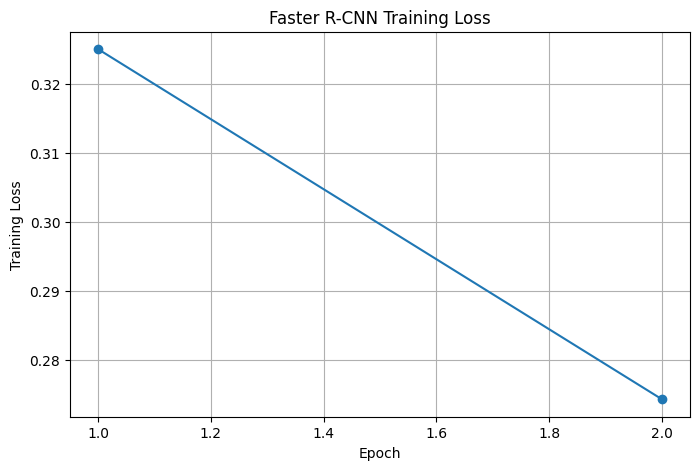

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_epochs + 1),
    detection_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Faster R-CNN Training Loss")
plt.grid(True)

plt.show()

In [15]:
model.eval()

metric = MeanAveragePrecision(
    box_format="xyxy",
    iou_type="bbox"
)

print("Calculating detection mAP...")

with torch.no_grad():

    for images, targets in val_detection_loader:

        images = [
            img.to(device)
            for img in images
        ]

        outputs = model(images)

        predictions = []

        for output in outputs:

            predictions.append({
                "boxes": output["boxes"].detach().cpu(),
                "scores": output["scores"].detach().cpu(),
                "labels": output["labels"].detach().cpu()
            })

        ground_truths = []

        for target in targets:

            ground_truths.append({
                "boxes": target["boxes"].cpu(),
                "labels": target["labels"].cpu()
            })

        metric.update(
            predictions,
            ground_truths
        )

results = metric.compute()

map_50 = float(results["map_50"])
map_5095 = float(results["map"])

print(f"mAP@50:     {map_50:.4f}")
print(f"mAP@50:95:  {map_5095:.4f}")

Calculating detection mAP...
mAP@50:     0.5513
mAP@50:95:  0.3051


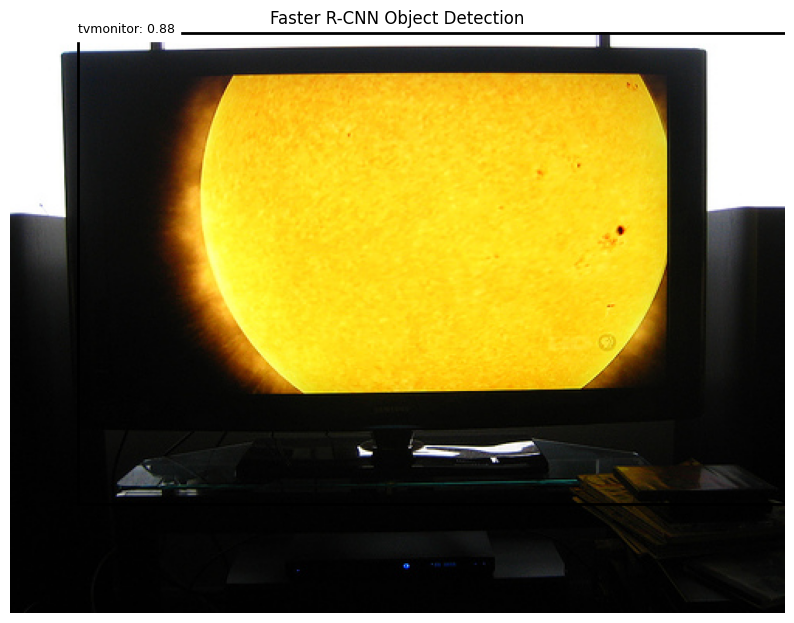

In [16]:
model.eval()

image, target = val_detection_dataset[0]

with torch.no_grad():

    prediction = model([
        image.to(device)
    ])[0]

image_np = image.permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(10, 8))
plt.imshow(image_np)

boxes = prediction["boxes"].cpu()
labels = prediction["labels"].cpu()
scores = prediction["scores"].cpu()

for box, label, score in zip(boxes, labels, scores):

    if score < 0.5:
        continue

    xmin, ymin, xmax, ymax = box.tolist()

    rect = plt.Rectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        fill=False,
        linewidth=2
    )

    plt.gca().add_patch(rect)

    class_name = VOC_CLASSES[label.item()]

    plt.text(
        xmin,
        ymin,
        f"{class_name}: {score:.2f}",
        fontsize=9,
        backgroundcolor="white"
    )

plt.title("Faster R-CNN Object Detection")
plt.axis("off")
plt.show()

In [17]:
voc_seg_train = VOCSegmentation(
    root=VOC_ROOT,
    year="2012",
    image_set="train",
    download=True
)

voc_seg_val = VOCSegmentation(
    root=VOC_ROOT,
    year="2012",
    image_set="val",
    download=True
)

print("Segmentation training images:", len(voc_seg_train))
print("Segmentation validation images:", len(voc_seg_val))

Segmentation training images: 1464
Segmentation validation images: 1449


In [18]:
class VOCSegmentationDataset(Dataset):

    def __init__(self, base_dataset, image_size=(128, 128)):

        self.dataset = base_dataset
        self.image_size = image_size

        self.image_transform = transforms.Compose([
            transforms.Resize(
                image_size,
                interpolation=transforms.InterpolationMode.BILINEAR
            ),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):

        image, mask = self.dataset[idx]

        image = self.image_transform(image)

        # Resize mask using nearest-neighbor
        mask = mask.resize(
            self.image_size,
            Image.Resampling.NEAREST
        )

        mask = torch.from_numpy(
            np.array(mask, dtype=np.int64)
        )

        return image, mask

In [19]:
seg_train_full = VOCSegmentationDataset(
    voc_seg_train
)

seg_val_full = VOCSegmentationDataset(
    voc_seg_val
)

SEG_TRAIN_SIZE = min(300, len(seg_train_full))
SEG_VAL_SIZE = min(100, len(seg_val_full))

seg_train_dataset = Subset(
    seg_train_full,
    range(SEG_TRAIN_SIZE)
)

seg_val_dataset = Subset(
    seg_val_full,
    range(SEG_VAL_SIZE)
)

print("Segmentation train:", len(seg_train_dataset))
print("Segmentation validation:", len(seg_val_dataset))

Segmentation train: 300
Segmentation validation: 100


In [20]:
seg_train_loader = DataLoader(
    seg_train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

seg_val_loader = DataLoader(
    seg_val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

print("Segmentation DataLoaders created.")

Segmentation DataLoaders created.


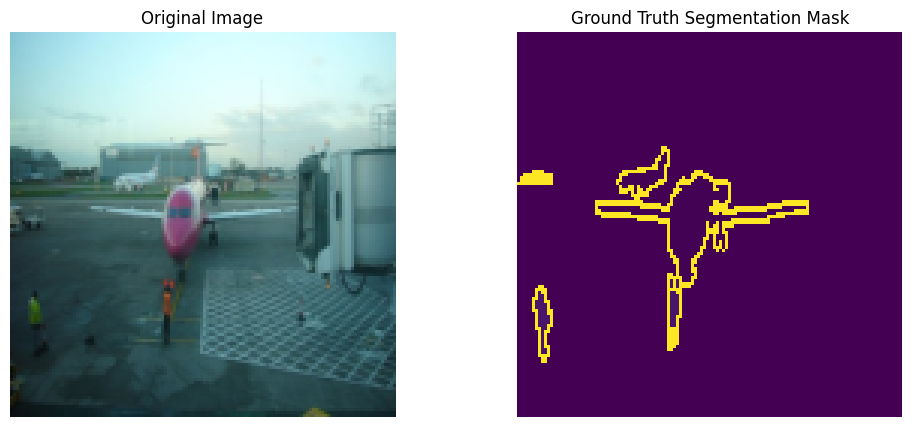

In [21]:
image, mask = seg_train_dataset[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image.permute(1, 2, 0))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask)
plt.title("Ground Truth Segmentation Mask")
plt.axis("off")

plt.show()

In [22]:
class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.block = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(out_channels),

            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.enc1 = DoubleConv(3, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(
            512,
            256,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(
            64,
            num_classes,
            kernel_size=1
        )

    def forward(self, x):

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        e3 = self.enc3(
            self.pool(e2)
        )

        b = self.bottleneck(
            self.pool(e3)
        )

        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [23]:
NUM_SEG_CLASSES = 21

unet = UNet(
    num_classes=NUM_SEG_CLASSES
).to(device)

print(unet)

UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Conv2d(128, 256, kernel_si

In [24]:
criterion = nn.CrossEntropyLoss(
    ignore_index=255
)

optimizer_unet = optim.Adam(
    unet.parameters(),
    lr=0.001
)

print("Loss function and optimizer created.")

Loss function and optimizer created.


In [25]:
num_seg_epochs = 2

train_seg_losses = []

print("Starting U-Net training...")

for epoch in range(num_seg_epochs):

    unet.train()

    running_loss = 0.0

    for images, masks in seg_train_loader:

        images = images.to(device)

        masks = masks.to(device)

        optimizer_unet.zero_grad()

        outputs = unet(images)

        loss = criterion(
            outputs,
            masks
        )

        loss.backward()

        optimizer_unet.step()

        running_loss += loss.item()

    avg_loss = (
        running_loss /
        len(seg_train_loader)
    )

    train_seg_losses.append(avg_loss)

    print(
        f"Epoch [{epoch+1}/{num_seg_epochs}] "
        f"Loss: {avg_loss:.4f}"
    )

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("U-Net training completed.")

Starting U-Net training...
Epoch [1/2] Loss: 2.2977
Epoch [2/2] Loss: 1.5222
U-Net training completed.


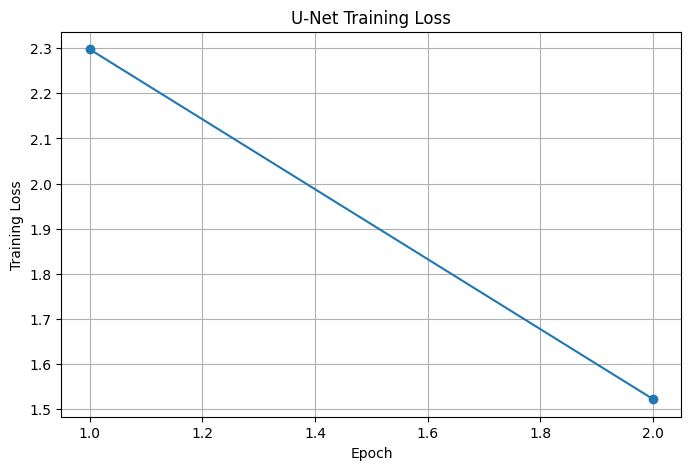

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, num_seg_epochs + 1),
    train_seg_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("U-Net Training Loss")
plt.grid(True)

plt.show()

In [27]:
def calculate_iou_dice(
    prediction,
    target,
    num_classes=21,
    ignore_index=255
):

    ious = []
    dices = []

    prediction = prediction.cpu()
    target = target.cpu()

    for class_id in range(num_classes):

        if class_id == 0:
            # Background can still be evaluated,
            # but it is included in the mean.
            pass

        pred_class = (
            prediction == class_id
        )

        target_class = (
            target == class_id
        )

        valid = (
            target != ignore_index
        )

        pred_class = pred_class & valid
        target_class = target_class & valid

        intersection = (
            pred_class & target_class
        ).sum().item()

        union = (
            pred_class | target_class
        ).sum().item()

        pred_area = pred_class.sum().item()
        target_area = target_class.sum().item()

        if union > 0:

            iou = intersection / union

            dice_denominator = (
                pred_area + target_area
            )

            if dice_denominator > 0:
                dice = (
                    2 * intersection /
                    dice_denominator
                )
            else:
                dice = 0.0

            ious.append(iou)
            dices.append(dice)

    mean_iou = (
        np.mean(ious)
        if ious else 0.0
    )

    mean_dice = (
        np.mean(dices)
        if dices else 0.0
    )

    return mean_iou, mean_dice

In [28]:
unet.eval()

all_ious = []
all_dices = []

print("Evaluating U-Net...")

with torch.no_grad():

    for images, masks in seg_val_loader:

        images = images.to(device)

        outputs = unet(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        for pred, target in zip(
            predictions,
            masks
        ):

            iou, dice = calculate_iou_dice(
                pred,
                target
            )

            all_ious.append(iou)
            all_dices.append(dice)

mean_iou = float(
    np.mean(all_ious)
)

mean_dice = float(
    np.mean(all_dices)
)

print(f"Mean IoU:   {mean_iou:.4f}")
print(f"Dice Score: {mean_dice:.4f}")

Evaluating U-Net...
Mean IoU:   0.2144
Dice Score: 0.2508


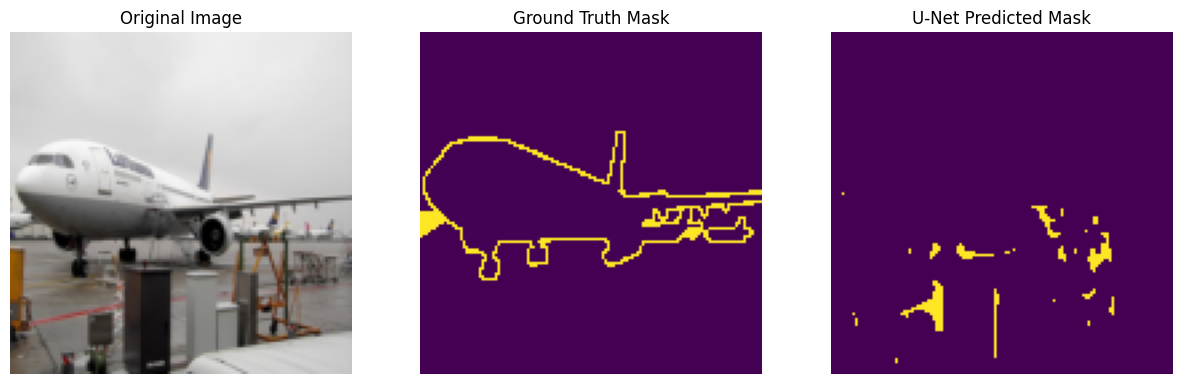

In [29]:
unet.eval()

image, ground_truth = seg_val_dataset[0]

with torch.no_grad():

    output = unet(
        image.unsqueeze(0).to(device)
    )

    prediction = torch.argmax(
        output,
        dim=1
    )[0].cpu()

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)

plt.imshow(
    image.permute(1, 2, 0)
)

plt.title("Original Image")
plt.axis("off")


plt.subplot(1, 3, 2)

plt.imshow(ground_truth)

plt.title("Ground Truth Mask")
plt.axis("off")


plt.subplot(1, 3, 3)

plt.imshow(prediction)

plt.title("U-Net Predicted Mask")
plt.axis("off")

plt.show()

In [30]:
performance = pd.DataFrame({
    "Model": [
        "Faster R-CNN",
        "U-Net"
    ],

    "Task": [
        "Object Detection",
        "Semantic Segmentation"
    ],

    "mAP@50": [
        map_50,
        np.nan
    ],

    "mAP@50:95": [
        map_5095,
        np.nan
    ],

    "IoU": [
        np.nan,
        mean_iou
    ],

    "Dice Score": [
        np.nan,
        mean_dice
    ]
})

print(performance.to_string(index=False))

       Model                  Task  mAP@50  mAP@50:95      IoU  Dice Score
Faster R-CNN      Object Detection 0.55131   0.305133      NaN         NaN
       U-Net Semantic Segmentation     NaN        NaN 0.214356    0.250789


# Comparative Analysis

## Faster R-CNN

Faster R-CNN was implemented for object detection using the PASCAL VOC 2012
dataset. The model performs object localization by predicting bounding boxes
and class labels for objects present in an image.

The detection performance was evaluated using mean Average Precision (mAP),
including mAP@50 and mAP@50:95.

## U-Net

U-Net was implemented for semantic image segmentation using the same
PASCAL VOC 2012 reference dataset.

The model assigns a semantic class to each pixel in an image.

The segmentation performance was evaluated using:

- Intersection over Union (IoU)
- Dice Score

## Comparison

Faster R-CNN and U-Net solve different computer vision problems.

Faster R-CNN focuses on identifying objects and locating them using bounding
boxes, while U-Net performs pixel-level semantic segmentation.

Therefore, mAP is appropriate for evaluating object detection, whereas IoU
and Dice Score are appropriate for evaluating segmentation.

Both approaches demonstrate different forms of computer vision analysis
using the same PASCAL VOC 2012 reference dataset.

In [31]:
print("=" * 60)
print("TASK 5 FINAL RESULTS")
print("=" * 60)

print("\nReference Dataset: PASCAL VOC 2012")

print("\nObject Detection - Faster R-CNN")
print(f"mAP@50     : {map_50:.4f}")
print(f"mAP@50:95  : {map_5095:.4f}")

print("\nSemantic Segmentation - U-Net")
print(f"Mean IoU    : {mean_iou:.4f}")
print(f"Dice Score  : {mean_dice:.4f}")

print("\nTask 5 completed.")

TASK 5 FINAL RESULTS

Reference Dataset: PASCAL VOC 2012

Object Detection - Faster R-CNN
mAP@50     : 0.5513
mAP@50:95  : 0.3051

Semantic Segmentation - U-Net
Mean IoU    : 0.2144
Dice Score  : 0.2508

Task 5 completed.


In [32]:
OUTPUT_DIR = "/content/Task5_outputs"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

# Save performance table
performance.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "task5_performance.csv"
    ),
    index=False
)

# Save Faster R-CNN
torch.save(
    model.state_dict(),
    os.path.join(
        OUTPUT_DIR,
        "faster_rcnn_voc2012.pth"
    )
)

# Save U-Net
torch.save(
    unet.state_dict(),
    os.path.join(
        OUTPUT_DIR,
        "unet_voc2012.pth"
    )
)

print("Files saved in:")
print(OUTPUT_DIR)

print(os.listdir(OUTPUT_DIR))

Files saved in:
/content/Task5_outputs
['faster_rcnn_voc2012.pth', 'task5_performance.csv', 'unet_voc2012.pth']
